In [1]:
import pandas as pd
df=pd.read_csv(r'C:\Users\SIDHARTH\Downloads\Main project\DL_final_df.csv')

In [2]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Desired sample sizes based on % targets
target_counts = {
    1: 350000,
    2: 470000,
    3: 620000,
    4: 800000,
    5: 980000
}

# Apply sampling
sampled = []

for rating, count in target_counts.items():
    group = df[df['rating'] == rating]
    sampled.append(group.iloc[:count])  # get top N

DL_final_df = pd.concat(sampled).reset_index(drop=True)

# Check result
print(DL_final_df['rating'].value_counts(normalize=True) * 100)

rating
5    30.434783
4    24.844720
3    19.254658
2    14.596273
1    10.869565
Name: proportion, dtype: float64


Bi LSTM

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,461 (10.15 MB)

 Trainable params: 2,659,461 (10.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
18113/18113 ━━━━━━━━━━━━━━━━━━━━ 365s 20ms/step - accuracy: 0.5362 - loss: 1.0667 - val_accuracy: 0.5944 - val_loss: 0.9306
Epoch 2/20
18113/18113 ━━━━━━━━━━━━━━━━━━━━ 378s 20ms/step - accuracy: 0.6020 - loss: 0.9163 - val_accuracy: 0.6039 - val_loss: 0.9091
Epoch 3/20
18113/18113 ━━━━━━━━━━━━━━━━━━━━ 376s 20ms/step - accuracy: 0.6218 - loss: 0.8730 - val_accuracy: 0.6051 - val_loss: 0.9067
Epoch 4/20
18113/18113 ━━━━━━━━━━━━━━━━━━━━ 358s 20ms/step - accuracy: 0.6374 - loss: 0.8389 - val_accuracy: 0.6044 - val_loss: 0.9129
Epoch 5/20
18113/18113 ━━━━━━━━━━━━━━━━━━━━ 385s 20ms/step - accuracy: 0.6538 - loss: 0.8065 - val_accuracy: 0.6029 - val_loss: 0.9201
Epoch 6/20
18113/18113 ━━━━━━━━━━━━━━━━━━━━ 375s 20ms/step - accuracy: 0.6674 - loss: 0.7778 - val_accuracy: 0.6009 - val_loss: 0.9479
20125/20125 ━━━━━━━━━━━━━━━━━━━━ 107s 5ms/step
Accuracy: 0.6052
Classification Report:

              precision    recall  f1-score   support

           1       0.60      0.61      0.61    

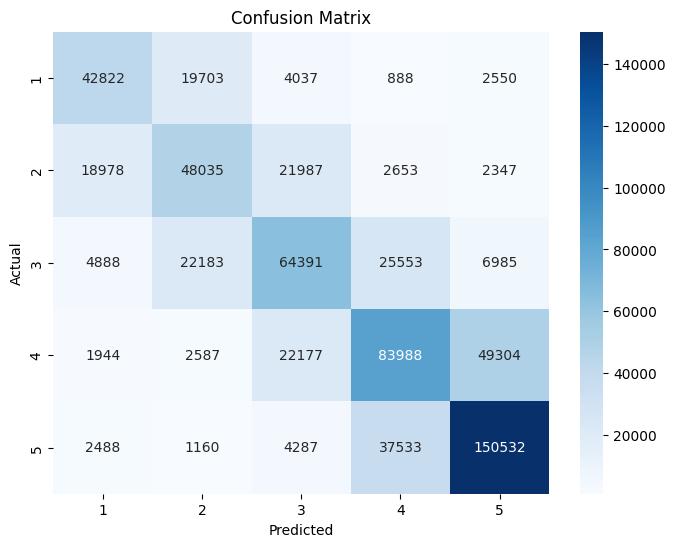

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# ----------------------
# Prepare data
# ----------------------
# Convert 'review' column to string type to handle potential non-string values
DL_final_df['review'] = DL_final_df['review'].astype(str)

X = DL_final_df['review']
y = DL_final_df['rating']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical,
    test_size=0.2,
    stratify=y_categorical,
    random_state=42
)

# Tokenization and padding
max_words = 20000
max_len = 150

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# ----------------------
# Build BiLSTM Model
# ----------------------
embedding_dim = 128
lstm_units = 64
num_classes = y_categorical.shape[1]

model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len))
model.add(Bidirectional(LSTM(lstm_units)))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Build model to show correct summary
model.build(input_shape=(None, max_len))
model.summary()

# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Add Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',   # you can also use 'val_accuracy'
    patience=3,           # number of epochs with no improvement before stopping
    restore_best_weights=True # restores weights from the epoch with best val_loss
)


# ----------------------
# Train Model
# ----------------------
history = model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,callbacks=[early_stop]
)

# ----------------------
# Evaluate Model
# ----------------------
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")

# Precision, Recall, F1-Score
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=[str(i) for i in le.classes_]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [3]:
n = 10
for rating in range(1, 6):
    filtered_reviews = df[df['rating'] == rating]['review'].dropna()
    sample_reviews = filtered_reviews.sample(n=min(n, len(filtered_reviews)), random_state=rating)

    # Print results
    print(f"\nShowing {min(n, len(filtered_reviews))} sample review(s) for Rating {rating}:\n")
    for i, review in enumerate(sample_reviews, 1):
        print(f"{i}. {review.strip()}\n")


Showing 10 sample review(s) for Rating 1:

1. what a bore

2. i had to really struggle to finish this the plot is lame the characters unbelievable and the dialogue actually the whole story flow is very stilted worst of all is the fact that this work is part of a series and it shows characters relationships situations etc pop up helterskelter some authors of series books go overboard in explaining things from the previous books in the series but this author did the extreme opposite she gave absolutely no background

3. goodkinds books are uneven some really good some not so good this work is hands down his worst a real stinker do not buy it under any circumstances dont even check it out of the library as it is a waste of your valuable time

4. couldnt get beyond the ridiculous scenario of remy finding a chained lion during a zombie attack that becomes her pet kitty the amount of suspension of disbelief for me as a reader was impossible the author has no concept of making connections so

In [ ]:
model.save('Model_DL2.h5')

In [ ]:
import pickle
with open('tokenizer2.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# 3. Save Label Encoder
with open('label_encoder2.pkl', 'wb') as f:
    pickle.dump(le, f)